# 23. KAIST observability: legacy versus optimized

Compare optimize=False and optimize=True on the **same loaded KAIST measurements**, using analyze_observability_inputs, the numerical entry point also called by src/kaist_dataset/observability.py.

The optimized dense path normally applies the nuisance projector through its retained SVD basis (with a legacy-projector fallback when retained nuisance condition exceeds 1e8), avoids full left SVD matrices, shares right decompositions within each target, and skips redundant production rank revalidation. The sparse path keeps its existing LSMR solves and optimizes diagnostics. Noise, column filtering, practical-rank thresholds, and CRLB definitions are unchanged. This notebook independently validates stored ranks outside timing.

This is a **CPU** benchmark of the refactoring intended to precede a GPU/NN implementation. No GPU or differentiable training loss is introduced here.

In [1]:
from pathlib import Path
import os
import sys

# Run from the repository root or notebooks directory.
REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                 if (p / "src/kaist_dataset/observability.py").is_file())
sys.path.insert(0, str(REPO_ROOT / "src"))

DATASET_ROOT = REPO_ROOT / "data/KAISTDataset/Urban16"
PROCESSED_DATA_DIR = None  # None uses the CLI's map-pose CSV discovery.
LIDAR = "left"
START_TIME = 0.0
END_TIME = 30.0  # Seconds from common overlap start; None uses the full sequence.
WINDOW_SIZE = 5.0
STEP_SIZE = 5.0
MAX_ANALYSIS_WINDOWS = 7  # Includes the initial warm-up/invalid snapshot.
N_PROCESSES = 1
BLAS_THREADS = 1  # Identical in both branches; inherited by spawned workers.
USE_SPARSE = False
REPEATS = 3
RUN_TARGET_BENCHMARK = True
OUTPUT_DIR = REPO_ROOT / "outputs/kaist_observability_optimization"

assert REPEATS >= 2
# Set before NumPy import; threadpool_limits also handles existing kernels.
for name in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[name] = str(BLAS_THREADS)
os.environ["MPLBACKEND"] = "Agg"


In [2]:
import gc
import json
import platform
from dataclasses import asdict, replace
from time import perf_counter

import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from IPython.display import Image, display
from threadpoolctl import threadpool_info, threadpool_limits

from kaist_dataset.observability import (
    KaistObservabilityConfig, load_observability_inputs, analyze_observability_inputs,
)
from calib_observability.diagnostics import (
    DEFAULT_PRACTICAL_RANK_POLICY, validate_stored_rank_against_matrix,
)
from calib_observability.factor_observability import (
    effective_target_observability_from_bundle_dense,
    effective_target_observability_from_bundle_sparse,
)

config = KaistObservabilityConfig(
    dataset_root=DATASET_ROOT, processed_data_dir=PROCESSED_DATA_DIR, lidar=LIDAR,
    start_time=START_TIME, end_time=END_TIME,
    window_size=WINDOW_SIZE, step_size=STEP_SIZE,
    max_analysis_windows=MAX_ANALYSIS_WINDOWS,
    n_processes=N_PROCESSES, use_sparse=USE_SPARSE, verbose=0,
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
t0 = perf_counter()
prepared = load_observability_inputs(config)
load_seconds = perf_counter() - t0
display(pd.DataFrame([{
    "dataset": str(DATASET_ROOT.resolve()),
    "load_and_prepare_seconds": load_seconds,
    "start": prepared.dataset.start_time,
    "end": prepared.dataset.end_time,
    **{f"{k}_Hz": v for k, v in prepared.metadata["effective_rates_hz"].items()},
}]))


,dataset,load_and_prepare_seconds,start,end,imu_Hz,lidar_Hz,ground_truth_Hz
0,/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16,39.277333,0.0,29.86,100.0,9.912927,98.039063


## Warm-up and numerical equivalence

Warm up **both complete analysis paths** before timing. Compare valid windows, available targets, physical projected matrices, singular values, rank decisions, observable-subspace projectors, and coordinate uncertainty. Compare subspaces rather than the signs of singular vectors. NaN and infinity retain their existing meaning.

Machine-rank differences are reported separately because roundoff-level singular values can cross a machine-epsilon cutoff when the projector is evaluated differently. Practical rank and boundedness must agree; every stored rank is also independently recomputed from its own matrix. Any failed assertion stops the benchmark.

In [3]:
with threadpool_limits(limits=BLAS_THREADS, user_api="blas"):
    warmup = {}
    for optimize in (False, True):
        t0 = perf_counter()
        warmup[optimize] = analyze_observability_inputs(prepared, replace(config, optimize=optimize))
        print(f"Warm-up optimize={optimize}: {perf_counter() - t0:.3f} s")

def dense(matrix):
    return matrix.toarray() if scipy.sparse.issparse(matrix) else np.asarray(matrix)

def compare_series(reference, optimized):
    rows = []
    assert len(reference.snapshots) == len(optimized.snapshots)
    assert any(s.is_valid for s in reference.snapshots), "No valid windows to benchmark."
    for before, after in zip(reference.snapshots, optimized.snapshots, strict=True):
        assert before.current_time == after.current_time
        assert before.is_valid == after.is_valid
        assert before.counts == after.counts
        assert before.target_results.keys() == after.target_results.keys()
        if not before.is_valid:
            continue
        expected_targets = set(reference.ranks) & set(before.bundle.calibration_column_slices)
        assert set(before.target_results) == expected_targets, "A target calculation failed silently."
        for variable in before.target_results:
            a, b = before.target_results[variable], after.target_results[variable]
            for result in (a, b):
                validate_stored_rank_against_matrix(
                    result.O_X_physical, result.practical_rank_diagnostics,
                    DEFAULT_PRACTICAL_RANK_POLICY,
                )
            A, B = dense(a.O_X_physical), dense(b.O_X_physical)
            relative_error = np.linalg.norm(B - A) / max(1.0, np.linalg.norm(A))
            assert relative_error < 1e-7, (before.current_time, variable, relative_error)
            assert a.effective_rank_O_X == b.effective_rank_O_X
            assert a.practical_rank_diagnostics.matrix_passed_absolute_gate == b.practical_rank_diagnostics.matrix_passed_absolute_gate
            np.testing.assert_array_equal(a.zero_target_column_mask, b.zero_target_column_mask)
            np.testing.assert_array_equal(a.retained_singular_value_mask, b.retained_singular_value_mask)
            np.testing.assert_allclose(a.singular_values_O_X, b.singular_values_O_X, atol=1e-7, rtol=1e-6)
            aa, bb = a.local_accuracy_diagnostics, b.local_accuracy_diagnostics
            assert aa.covariance_kind == bb.covariance_kind
            assert aa.meets_target == bb.meets_target
            np.testing.assert_array_equal(aa.coordinate_is_fully_bounded, bb.coordinate_is_fully_bounded)
            np.testing.assert_allclose(aa.observable_projector, bb.observable_projector, atol=1e-6, rtol=1e-6)
            np.testing.assert_allclose(aa.coordinate_std_bounds, bb.coordinate_std_bounds, atol=1e-7, rtol=1e-5)
            np.testing.assert_allclose(aa.retained_mode_std_bounds, bb.retained_mode_std_bounds, atol=1e-7, rtol=1e-5)
            np.testing.assert_allclose(aa.physical_information_matrix, bb.physical_information_matrix, atol=1e-6, rtol=1e-6)
            for field in ("full_covariance", "observable_subspace_pseudocovariance"):
                av, bv = getattr(aa, field), getattr(bb, field)
                if av is None:
                    assert bv is None
                else:
                    np.testing.assert_allclose(av, bv, atol=1e-6, rtol=1e-5)
            rows.append({
                "time": before.current_time, "variable": variable,
                "rows": A.shape[0], "columns": A.shape[1],
                "practical_rank": a.effective_rank_O_X,
                "machine_rank_legacy": a.machine_rank_O_X,
                "machine_rank_optimized": b.machine_rank_O_X,
                "relative_matrix_error": relative_error,
                "covariance_kind": aa.covariance_kind,
            })
    assert rows, "No target diagnostics were compared."
    return pd.DataFrame(rows)

with threadpool_limits(limits=BLAS_THREADS, user_api="blas"):
    comparison = compare_series(warmup[False], warmup[True])
display(comparison)
comparison.to_csv(OUTPUT_DIR / "numerical_comparison.csv", index=False)


Warm-up optimize=False: 6.157 s


Warm-up optimize=True: 4.934 s


,time,variable,rows,columns,practical_rank,machine_rank_legacy,machine_rank_optimized,relative_matrix_error,covariance_kind
0,5.00,T_B_I,693,6,3,3,3,1.350738e-10,observable_subspace_only
1,5.00,b_g,693,3,3,3,3,1.080857e-11,full
2,5.00,tau_I,693,1,1,1,1,6.639488e-12,full
3,5.00,tau_L,693,1,1,1,1,1.847190e-11,full
4,10.00,T_B_I,669,6,3,3,3,2.088088e-10,observable_subspace_only
5,10.00,b_g,669,3,3,3,3,2.373889e-11,full
6,10.00,tau_I,669,1,1,1,1,2.478601e-11,full
7,10.00,tau_L,669,1,1,1,1,1.891597e-11,full
8,15.00,T_B_I,678,6,3,3,3,2.120178e-10,observable_subspace_only
9,15.00,b_g,678,3,3,3,3,0.000000e+00,full


## Analysis timings

Loading, plotting, exports, garbage collection, and comparison assertions are outside the timed region. Analysis timings include factor/Jacobian assembly, projection, diagnostics, and snapshot/display-array construction, exactly as in the CLI. Alternate branch order between repeats to reduce order bias. Equal process and BLAS settings isolate the effect of optimize; change them above and rerun to compare threading arrangements.

The initial snapshot can be invalid because no complete factor window exists yet. Report both total snapshots and valid windows; timings use the identical schedule for both branches.

In [4]:
timings = []
last_series = {}
with threadpool_limits(limits=BLAS_THREADS, user_api="blas"):
    runtime_threads = threadpool_info()
    for repeat in range(REPEATS):
        order = (False, True) if repeat % 2 == 0 else (True, False)
        for optimize in order:
            gc.collect()
            t0 = perf_counter()
            series = analyze_observability_inputs(prepared, replace(config, optimize=optimize))
            elapsed = perf_counter() - t0
            valid = sum(s.is_valid for s in series.snapshots)
            assert valid > 0
            timings.append({
                "repeat": repeat + 1, "optimize": optimize,
                "seconds": elapsed, "snapshots": len(series.snapshots),
                "valid_windows": valid, "seconds_per_valid_window": elapsed / valid,
            })
            # Correctness checks are outside timing, on every repeat.
            compare_series(warmup[False], series)
            last_series[optimize] = series
            print(f"repeat={repeat + 1} optimize={optimize}: {elapsed:.3f} s")

timing_table = pd.DataFrame(timings)
summary = timing_table.groupby("optimize").agg(
    median_seconds=("seconds", "median"),
    min_seconds=("seconds", "min"),
    max_seconds=("seconds", "max"),
    median_seconds_per_valid_window=("seconds_per_valid_window", "median"),
)
speedup = summary.loc[False, "median_seconds"] / summary.loc[True, "median_seconds"]
display(timing_table)
display(summary)
print(f"Median analysis speedup: {speedup:.2f}x")
timing_table.to_csv(OUTPUT_DIR / "analysis_timings.csv", index=False)
summary.to_csv(OUTPUT_DIR / "analysis_summary.csv")


repeat=1 optimize=False: 5.820 s


repeat=1 optimize=True: 4.993 s


repeat=2 optimize=True: 5.086 s


repeat=2 optimize=False: 6.028 s


repeat=3 optimize=False: 5.712 s


repeat=3 optimize=True: 5.113 s


,repeat,optimize,seconds,snapshots,valid_windows,seconds_per_valid_window
0,1,False,5.820058,7,6,0.970010
1,1,True,4.992592,7,6,0.832099
2,2,True,5.085920,7,6,0.847653
3,2,False,6.028431,7,6,1.004739
4,3,False,5.711624,7,6,0.951937
5,3,True,5.113194,7,6,0.852199


,median_seconds,min_seconds,max_seconds,median_seconds_per_valid_window
optimize,,,,
False,5.820058,5.711624,6.028431,0.970010
True,5.085920,4.992592,5.113194,0.847653


Median analysis speedup: 1.14x


## Projection and diagnostics on a preassembled KAIST window

This second measurement uses a real Jacobian bundle from the largest valid benchmark window. It excludes assembly and shows whether improvements to nuisance elimination and diagnostics are hidden by the cost of building factors. The full analysis timing above remains the main result.

The matrix memory estimate below is only the size of **one avoided dense projector**, not measured peak memory or total saved memory. Extremely ill-conditioned nuisance blocks use the compatibility fallback and still allocate the projector.

In [5]:
target_timings = []
target_summary = None
if RUN_TARGET_BENCHMARK:
    snapshot = max((s for s in warmup[False].snapshots if s.is_valid),
                   key=lambda s: s.bundle.J.shape[0])
    bundle = snapshot.bundle
    targets = tuple(snapshot.target_results)
    project = (effective_target_observability_from_bundle_sparse if USE_SPARSE
               else effective_target_observability_from_bundle_dense)
    lidar_rate = prepared.metadata["effective_rates_hz"]["lidar"]
    def analyze_targets(optimize):
        return {
            name: project(
                bundle, name, optimize=optimize, normalization="physical_then_column",
                lidar_rate_hz=lidar_rate, tau_target_std_seconds=1.0 / lidar_rate,
            )
            for name in targets
        }
    with threadpool_limits(limits=BLAS_THREADS, user_api="blas"):
        for optimize in (False, True):
            analyze_targets(optimize)
        for repeat in range(REPEATS):
            for optimize in ((False, True) if repeat % 2 == 0 else (True, False)):
                gc.collect()
                t0 = perf_counter()
                results = analyze_targets(optimize)
                elapsed = perf_counter() - t0
                assert set(results) == set(targets)
                target_timings.append({"repeat": repeat + 1, "optimize": optimize, "seconds": elapsed})
    target_table = pd.DataFrame(target_timings)
    target_summary = target_table.groupby("optimize").seconds.agg(["median", "min", "max"])
    display(target_summary)
    print(f"Projection + diagnostics speedup: {target_summary.loc[False, 'median'] / target_summary.loc[True, 'median']:.2f}x")
    rows, columns = bundle.J.shape
    print(f"Preassembled J shape: {rows} x {columns}; targets: {targets}")
    if not USE_SPARSE:
        print(f"One avoided float64 projector: {8 * rows * rows / 2**20:.2f} MiB")
    target_table.to_csv(OUTPUT_DIR / "target_timings.csv", index=False)


,median,min,max
optimize,,,
False,0.786184,0.775662,0.856077
True,0.600441,0.591474,0.612067


Projection + diagnostics speedup: 1.31x
Preassembled J shape: 693 x 569; targets: ('T_B_I', 'b_g', 'tau_I', 'tau_L')
One avoided float64 projector: 3.66 MiB


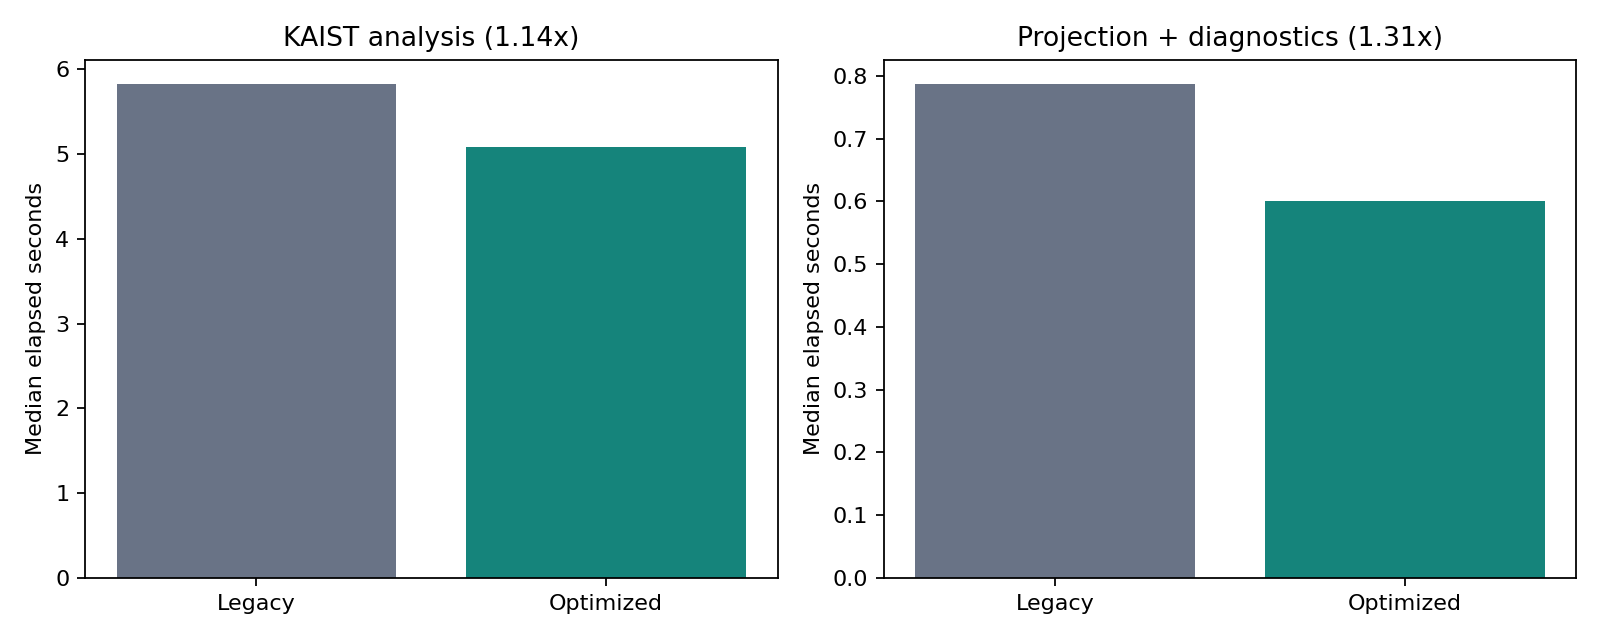

Saved timing tables, numerical checks, plot, and environment metadata to /home/camel/Skoltech/phd_proposal/outputs/kaist_observability_optimization


In [6]:
fig, axes = plt.subplots(1, 2 if target_summary is not None else 1, figsize=(10, 4), squeeze=False)
axes[0, 0].bar(["Legacy", "Optimized"], summary["median_seconds"], color=["#697386", "#15847b"])
axes[0, 0].set(title=f"KAIST analysis ({speedup:.2f}x)", ylabel="Median elapsed seconds")
if target_summary is not None:
    ratio = target_summary.loc[False, "median"] / target_summary.loc[True, "median"]
    axes[0, 1].bar(["Legacy", "Optimized"], target_summary["median"], color=["#697386", "#15847b"])
    axes[0, 1].set(title=f"Projection + diagnostics ({ratio:.2f}x)", ylabel="Median elapsed seconds")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "timing_comparison.png", dpi=160)
display(Image(filename=str(OUTPUT_DIR / "timing_comparison.png")))
plt.close(fig)

metadata = {
    "config": asdict(config), "repeats": REPEATS, "blas_threads": BLAS_THREADS,
    "python": sys.version, "numpy": np.__version__, "scipy": scipy.__version__,
    "platform": platform.platform(), "threadpools_during_timing": runtime_threads,
    "load_and_prepare_seconds": load_seconds, "analysis_speedup": float(speedup),
    "prepared_metadata": prepared.metadata,
}
def json_default(value):
    if isinstance(value, Path): return str(value)
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, np.generic): return value.item()
    raise TypeError(type(value).__name__)
(OUTPUT_DIR / "benchmark_metadata.json").write_text(json.dumps(metadata, indent=2, default=json_default))
print(f"Saved timing tables, numerical checks, plot, and environment metadata to {OUTPUT_DIR}")


## Using the optimized pipeline

Python:
~~~python
config = KaistObservabilityConfig(dataset_root=DATASET_ROOT, optimize=True)
# Already loaded data: analysis only.
series = analyze_observability_inputs(prepared, config)
# Or load and export the CLI's complete report:
# from kaist_dataset.observability import run_observability
# run_observability(config)
~~~

CLI:
~~~bash
python src/kaist_dataset/run_kaist_observability.py /path/to/Urban16 --optimize
python src/kaist_dataset/run_kaist_observability.py /path/to/Urban16 --no-optimize
~~~

The default remains False. Speedups depend on the window size, dataset segment, CPU, thread counts, and dense/sparse setting. To test scaling, increase WINDOW_SIZE and MAX_ANALYSIS_WINDOWS, rerun both branches, and retain the generated metadata. Sparse elimination and factor assembly are unchanged. This benchmark does not claim GPU throughput or training-backward performance.